# Análise de Mortalidade 2026

**Curso de Ciência de Dados — Projeto Final**

Este notebook foi escrito de forma **simples e comentada**, usando três
ferramentas: **pandas** (para trabalhar com tabelas), **matplotlib** (para os
gráficos) e um pouco de **numpy** (para alguns cálculos).

### Arquivos usados
- `MORTALIDADE_GERAL_2026.csv` — a base bruta de óbitos (uma linha por óbito).
- `MUNICIPIOS.xlsx` — nome do município, estado (UF) e população.
- `CIDs_com_descricao.xlsx` — a descrição de cada código de doença (CID).



## Explicação do dataset:<br>
A base de dados em questão foi retirada do dados.gov e traz informações sobre mortalidade no ano de 2026, temos dados dos óbitos ocorridos entre 01/01/2026 e 31/05/2026.
link da base de dados: Mortalidade Geral 2026 1ª prévia em https://dados.gov.br/dados/conjuntos-dados/sim-1979-2019 <br>

#### Colunas:
**contador: identificador do registro<br>**
**TIPOOBITO: se é um óbito fetal ou não<br>**
**DTOBITO: data em que ocorreu o óbito<br>**
**DTNASC: data de nascimento<br>**
**IDADE: campo que mostra em minutos, horas, dias ou anos<br>**
**SEXO: M,1 - masculino; F,2 - feminino; I,0,9 - ignorado<br>**
**RACACOR: 1- branca; 2-preta; 3-amarela; 4-parda; 5-indigena<br>**
**ESTCIV: 1– Solteiro; 2 – Casado; 3 – Viúvo; 4 – Separado judicialmente/divorciado; 5 – União estável; 9 – Ignorado<br>**
**ESC2010:0 – Sem escolaridade; 1 – Fundamental I (1ª a 4ª série); 2 – Fundamental II (5ª a 8ª série); 3 – Médio (antigo 2º Grau); 4 – Superior incompleto; 5 – Superior completo; 9 – Ignorado<br>**
**OCUP: só preenchido se o cammpo idade for maior que 5 anos. Codigo de acordo com a CBO 2002<br>**
**CODMUNRES: codigo de municipio de residencia do falecido<br>**
**CODMUNOCOR: codigo de municipio onde ocorreu o óbito<br>**
**CAUSABAS: causa básica da morte (CID)<br>**
**ACIDTRAB: 1- sim; 2-não; 9-ignorado <br>**


## As perguntas que queremos responder

1. Quantidade de mortes por mês
2. Média, mediana e desvio padrão da idade por mês
3. Quantidade de mortes por estado, no semestre
4. Quantidade de mortes por CID
5. As 10 maiores causas e o percentual de cada uma
6. Quantidade de mortes por faixa de idade
7. As 10 cidades onde mais pessoas morreram
8. População de cada cidade, para ver o percentual de óbitos por população
9. IQR da idade, histograma, curva de distribuição e coluna de z-score

## Passo 1 — Importar as ferramentas


- **pandas** é como um "Excel dentro do Python": guarda os dados em tabelas
  chamadas *DataFrame*.
- **matplotlib** serve para desenhar os gráficos.
- **numpy** é uma biblioteca de cálculos com números. Ela trabalha com muitos
  valores de uma vez, de forma rápida. Usada para calculo do IQR e Z-score.

O `as pd`, `as plt` e `as np` são apenas apelidos curtos, para escrevermos menos.

In [188]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Passo 2 — Ler a base de óbitos

O arquivo é grande e tem muitas colunas. Para o trabalho ficar leve, lemos
**apenas as colunas que vamos usar**. O separador do arquivo é o ponto e vírgula
(`;`), e lemos tudo como texto (`dtype=str`) para não perder zeros à esquerda dos
códigos.

In [189]:
colunas = ['contador','DTOBITO', 'DTNASC', 'SEXO', 'IDADE', 'RACACOR','CODMUNRES', 'CODMUNOCOR', 'CAUSABAS']

mortes = pd.read_csv("MORTALIDADE_GERAL_2026.csv",sep=';', usecols=colunas, dtype=str)

print('Quantidade de linhas e colunas:', mortes.shape)
mortes.head()

Quantidade de linhas e colunas: (506531, 9)


,contador,DTOBITO,DTNASC,IDADE,SEXO,RACACOR,CODMUNRES,CODMUNOCOR,CAUSABAS
0,1,03042026,06021928,498,2,1,310620,310620,I499
1,2,11032026,02081935,490,1,1,430258,430258,C857
2,3,28012026,24051974,451,1,4,230530,230530,I210
3,4,07022026,08021929,496,2,1,230530,230530,R961
4,5,19022026,17081930,495,2,1,230530,230530,R961


## Passo 3 — Um primeiro diagnóstico

Antes de analisar, é importante olhar a "saúde" dos dados: quantas linhas,
quantos valores estão faltando em cada coluna e se há linhas repetidas.

In [190]:
# Quantos valores estao faltando em cada coluna
print('Valores faltando por coluna:')
print(mortes.isnull().sum())

Valores faltando por coluna:
contador         0
DTOBITO          0
DTNASC         627
IDADE            0
SEXO             0
RACACOR       6245
CODMUNRES        0
CODMUNOCOR       0
CAUSABAS         0
dtype: int64


In [191]:
faltantes = pd.DataFrame({
    'Quantidade': mortes.isnull().sum(),
    'Percentual': (mortes.isnull().mean()*100).round(2)
})
faltantes

,Quantidade,Percentual
contador,0,0.00
DTOBITO,0,0.00
DTNASC,627,0.12
IDADE,0,0.00
SEXO,0,0.00
RACACOR,6245,1.23
CODMUNRES,0,0.00
CODMUNOCOR,0,0.00
CAUSABAS,0,0.00


In [192]:
# Verificar linhas totalmente repetidas
repetidas = mortes.duplicated().sum()
print('Linhas totalmente repetidas:', repetidas)

# Removemos apenas as linhas 100% iguais (provaveis duplicatas de digitacao).
# Nao removemos por poucas colunas, senao apagariamos obitos de pessoas
# diferentes que por acaso tem os mesmos dados.
mortes = mortes.drop_duplicates()
print('Linhas apos remover repetidas:', len(mortes))

Linhas totalmente repetidas: 0
Linhas apos remover repetidas: 506531


In [193]:
mortalidade = pd.read_csv("MORTALIDADE_GERAL_2026.csv", sep=';',dtype=str)
mortalidade = mortalidade.drop(columns=['contador'])


In [194]:
mortalidade.head(5)


,ORIGEM,TIPOBITO,DTOBITO,HORAOBITO,NATURAL,CODMUNNATU,DTNASC,IDADE,SEXO,RACACOR,ESTCIV,ESC,ESC2010,SERIESCFAL,OCUP,CODMUNRES,LOCOCOR,CODESTAB,CODMUNOCOR,IDADEMAE,ESCMAE,ESCMAE2010,SERIESCMAE,OCUPMAE,QTDFILVIVO,QTDFILMORT,GRAVIDEZ,SEMAGESTAC,GESTACAO,PARTO,OBITOPARTO,PESO,TPMORTEOCO,OBITOGRAV,OBITOPUERP,ASSISTMED,EXAME,CIRURGIA,NECROPSIA,LINHAA,LINHAB,LINHAC,LINHAD,LINHAII,CAUSABAS,CB_PRE,COMUNSVOIM,DTATESTADO,CIRCOBITO,ACIDTRAB,FONTE,NUMEROLOTE,DTINVESTIG,DTCADASTRO,ATESTANTE,STCODIFICA,CODIFICADO,VERSAOSIST,VERSAOSCB,FONTEINV,DTRECEBIM,ATESTADO,DTRECORIGA,OPOR_DO,CAUSAMAT,ESCMAEAGR1,ESCFALAGR1,STDOEPIDEM,STDONOVA,DIFDATA,NUDIASOBCO,DTCADINV,TPOBITOCOR,DTCONINV,FONTES,TPRESGINFO,TPNIVELINV,DTCADINF,MORTEPARTO,DTCONCASO,ALTCAUSA,CAUSABAS_O,TPPOS,TP_ALTERA,CB_ALT
0,1,2,03042026,2315,NaN,NaN,06021928,498,2,1,3,5,NaN,NaN,999992,310620,3,NaN,310620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2,2,2,*J960,NaN,NaN,NaN,*I499*F03X,I499,NaN,NaN,03042026,NaN,NaN,NaN,20260018,NaN,11052026,1,S,S,3.2.30,4.3,NaN,28052026,J960/ / / /I499*F03,28052026,55,NaN,NaN,NaN,0,0,055,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I499,N,NaN,NaN
1,1,2,11032026,0845,843,431690,02081935,490,1,1,2,3,1,4,999993,430258,3,NaN,430258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*E440,*C857,NaN,NaN,NaN,C857,NaN,NaN,11032026,NaN,NaN,NaN,20260006,NaN,04052026,2,S,S,3.2.30,4.3,NaN,21052026,E440/C857,21052026,71,NaN,NaN,02,0,1,071,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C857,N,NaN,NaN
2,1,2,28012026,1340,823,230530,24051974,451,1,4,9,3,2,NaN,622020,230530,1,2561336,230530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,9,*I469,*I210,*Z729,NaN,NaN,I210,NaN,NaN,28012026,NaN,NaN,NaN,20260007,NaN,19022026,5,S,S,3.2.30,4.3,NaN,19022026,I469/I210 /Z729 / /,19022026,22,NaN,NaN,11,0,1,022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I210,N,NaN,NaN
3,1,2,07022026,NaN,823,230530,08021929,496,2,1,3,2,1,NaN,622020,230530,3,NaN,230530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,9,*R961,NaN,NaN,NaN,NaN,R961,NaN,NaN,07022026,NaN,NaN,NaN,20260007,NaN,19022026,1,S,S,3.2.30,4.3,NaN,19022026,R961/ / / /,19022026,12,NaN,NaN,10,0,1,012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R961,N,NaN,NaN
4,1,2,19022026,1620,823,230530,17081930,495,2,1,1,1,0,NaN,622020,230530,1,2561336,230530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,9,*J960,*R961,NaN,NaN,NaN,R961,NaN,NaN,19022026,NaN,NaN,NaN,20260008,NaN,26022026,1,S,S,3.2.30,4.3,NaN,27022026,J960/R961,27022026,8,NaN,NaN,00,0,1,008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R961,N,NaN,NaN


In [195]:
pd.set_option('display.max_columns',None)

In [196]:
mortalidade_rep = mortalidade[mortalidade.duplicated(keep=False)]
mortalidade_rep

,ORIGEM,TIPOBITO,DTOBITO,HORAOBITO,NATURAL,CODMUNNATU,DTNASC,IDADE,SEXO,RACACOR,ESTCIV,ESC,ESC2010,SERIESCFAL,OCUP,CODMUNRES,LOCOCOR,CODESTAB,CODMUNOCOR,IDADEMAE,ESCMAE,ESCMAE2010,SERIESCMAE,OCUPMAE,QTDFILVIVO,QTDFILMORT,GRAVIDEZ,SEMAGESTAC,GESTACAO,PARTO,OBITOPARTO,PESO,TPMORTEOCO,OBITOGRAV,OBITOPUERP,ASSISTMED,EXAME,CIRURGIA,NECROPSIA,LINHAA,LINHAB,LINHAC,LINHAD,LINHAII,CAUSABAS,CB_PRE,COMUNSVOIM,DTATESTADO,CIRCOBITO,ACIDTRAB,FONTE,NUMEROLOTE,DTINVESTIG,DTCADASTRO,ATESTANTE,STCODIFICA,CODIFICADO,VERSAOSIST,VERSAOSCB,FONTEINV,DTRECEBIM,ATESTADO,DTRECORIGA,OPOR_DO,CAUSAMAT,ESCMAEAGR1,ESCFALAGR1,STDOEPIDEM,STDONOVA,DIFDATA,NUDIASOBCO,DTCADINV,TPOBITOCOR,DTCONINV,FONTES,TPRESGINFO,TPNIVELINV,DTCADINF,MORTEPARTO,DTCONCASO,ALTCAUSA,CAUSABAS_O,TPPOS,TP_ALTERA,CB_ALT
2471,1,2,24022026,NaN,NaN,NaN,NaN,999,0,NaN,9,9,9,NaN,NaN,432300,9,NaN,432300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*R99X,NaN,NaN,NaN,NaN,R99,NaN,431490,24022026,NaN,NaN,NaN,20260021,NaN,18052026,3,S,S,3.2.30,4.3,NaN,21052026,R99,21052026,86,NaN,NaN,09,0,1,086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R99,N,NaN,NaN
272121,1,2,09012026,NaN,NaN,NaN,NaN,999,0,4,9,9,9,NaN,998999,330000,5,NaN,330455,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,*R99X,NaN,NaN,NaN,NaN,R99,NaN,330455,09012026,NaN,NaN,NaN,20260018,NaN,04022026,3,S,S,3.2.30,4.3,NaN,04022026,R99,04022026,26,NaN,NaN,09,0,1,026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R99,N,NaN,NaN
272122,1,2,09012026,NaN,NaN,NaN,NaN,999,0,4,9,9,9,NaN,998999,330000,5,NaN,330455,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,*R99X,NaN,NaN,NaN,NaN,R99,NaN,330455,09012026,NaN,NaN,NaN,20260018,NaN,04022026,3,S,S,3.2.30,4.3,NaN,04022026,R99,04022026,26,NaN,NaN,09,0,1,026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R99,N,NaN,NaN
297776,1,2,08042026,1538,833,330455,08042026,056,2,1,NaN,NaN,NaN,NaN,NaN,330510,1,2269783,330455,35,4,3,NaN,521110,05,00,3,34,4,2,3,1435,NaN,NaN,NaN,1,NaN,NaN,2,*P209,*Q897,NaN,NaN,*P071,Q897,NaN,NaN,09042026,NaN,NaN,NaN,20260016,NaN,15042026,2,S,S,3.2.30,4.3,NaN,27042026,P209/Q897*P071,27042026,19,NaN,12,NaN,0,1,019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q897,NaN,NaN,NaN
297777,1,2,08042026,1538,833,330455,08042026,056,2,1,NaN,NaN,NaN,NaN,NaN,330510,1,2269783,330455,35,4,3,NaN,521110,05,00,3,34,4,2,3,1435,NaN,NaN,NaN,1,NaN,NaN,2,*P209,*Q897,NaN,NaN,*P071,Q897,NaN,NaN,09042026,NaN,NaN,NaN,20260016,NaN,15042026,2,S,S,3.2.30,4.3,NaN,27042026,P209/Q897*P071,27042026,19,NaN,12,NaN,0,1,019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q897,NaN,NaN,NaN
456203,1,2,17032026,NaN,NaN,NaN,NaN,999,0,NaN,NaN,NaN,NaN,NaN,NaN,432300,4,NaN,432300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*R99X,NaN,NaN,NaN,NaN,R99,NaN,431490,17032026,NaN,NaN,NaN,20260021,NaN,18052026,3,S,S,3.2.30,4.3,NaN,21052026,R99,21052026,65,NaN,NaN,NaN,0,1,065,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R99,N,NaN,NaN
456204,1,2,17032026,NaN,NaN,NaN,NaN,999,0,NaN,NaN,NaN,NaN,NaN,NaN,432300,4,NaN,432300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*R99X,NaN,NaN,NaN,NaN,R99,NaN,431490,17032026,NaN,NaN,NaN,20260021,NaN,18052026,3,S,S,3.2.30,4.3,NaN,21052026,R99,21052026,65,NaN,NaN,NaN,0,1,065,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R99,N,NaN,NaN
459037,1,2,24022026,NaN,NaN,NaN,NaN,999,0,NaN,9,9,9,NaN,NaN,432300,9,NaN,432300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*R99X,NaN,NaN,NaN,NaN,R99,NaN,431490,24022026,NaN,NaN,NaN,20260021,NaN,18052026,3,S,S,3.2.30,4.3,NaN,21052026,R99,21052026,86,NaN,NaN,09,0,1,086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R99,N,NaN,NaN


**Obs: vimos que se tirarmos o contador do dataset, algumas linhas 100% duplicadas surgem.
de acordo com a nossa verificação, os ids 297776 e 297777 devem ser considerados pois tratam de morte de gemeos, onde a mãe teve uma gravidez de 3 ou mais bebês.<br>
Os outros registros duplicados, apesar de não terem muitos dados especificos, optamos por ficar, pois pode significar a morte de uma pessoa que não foi identificada**

## Passo 4 — Descobrir o mês de cada óbito

A data vem como texto no formato dia-mês-ano (por exemplo, `01012026` é
01/01/2026). Quando o dia é menor que 10, o número vem com 7 dígitos, então
primeiro completamos com um zero à esquerda (`zfill(8)`) para todos ficarem com
8 dígitos. Depois pegamos os dois dígitos do meio, que são o **mês**.

In [197]:
mortes['DTOBITO'] = mortes['DTOBITO'].str.zfill(8)
mortes['MES'] = mortes['DTOBITO'].str[2:4]

print('Meses encontrados na base:')
print(mortes['MES'].value_counts().sort_index())

Meses encontrados na base:
MES
01    121045
02    106254
03    122882
04    107511
05     48839
Name: count, dtype: int64


## Passo 5 — Transformar a idade em anos

Nesta base a idade vem em um **código**: o primeiro dígito diz a unidade e os
dois últimos a quantidade. As unidades são:

- `0`, `1`, `2`, `3` → minutos, horas, dias ou meses (ou seja, **menos de 1 ano**)
- `4` → anos
- `5` → 100 anos ou mais
- `9` → idade ignorada

Escrevemos uma função simples com `if` para traduzir o código em idade em anos.
Quem tem menos de 1 ano recebe idade 0; idade ignorada vira vazio (`None`).

In [198]:
def idade_em_anos(codigo):
    # Se estiver vazio ou muito curto, nao da para calcular
    if pd.isna(codigo) or len(str(codigo)) < 3:
        return None
    codigo = str(codigo)
    unidade = codigo[0]           # primeiro digito
    quantidade = int(codigo[1:])  # os dois ultimos digitos
    if unidade == '4':
        return quantidade
    if unidade == '5':
        return 100 + quantidade
    if unidade in ['0', '1', '2', '3']:
        return 0
    return None  # unidade '9' = idade ignorada

# apply aplica a nossa funcao em cada linha da coluna IDADE
mortes['IDADE_ANOS'] = mortes['IDADE'].apply(idade_em_anos)

print('Idades validas:', mortes['IDADE_ANOS'].notna().sum())
mortes[['IDADE', 'IDADE_ANOS']].head()

Idades validas: 506113


,IDADE,IDADE_ANOS
0,498,98.0
1,490,90.0
2,451,51.0
3,496,96.0
4,495,95.0


## Passo 6 — Criar a faixa de idade

Também com uma função `if`, colocamos cada pessoa em uma faixa etária. Isso vai
ajudar na pergunta 6.

In [199]:
bins = [-float('inf'), 2, 9, 19, 59, float('inf')]
labels = [
    '1) Ate 2 anos',
    '2) 3 a 9 anos',
    '3) 10 a 19 anos',
    '4) 20 a 59 anos',
    '5) 60 anos ou mais'
]

mortes['FAIXA_IDADE'] = pd.cut(
    mortes['IDADE_ANOS'],
    bins=bins,
    labels=labels
)

mortes[['IDADE_ANOS', 'FAIXA_IDADE']].head()


,IDADE_ANOS,FAIXA_IDADE
0,98.0,5) 60 anos ou mais
1,90.0,5) 60 anos ou mais
2,51.0,4) 20 a 59 anos
3,96.0,5) 60 anos ou mais
4,95.0,5) 60 anos ou mais


## Passo 7 - Substituir os cógigos pelo significado nos campos de raça e sexo e tratar os casos nulos

**SEXO: M,1 - masculino; F,2 - feminino; I,0,9 - ignorado<br>**
**RACACOR: 1- branca; 2-preta; 3-amarela; 4-parda; 5-indigena<br>**

In [200]:
mortes['SEXO'].dtype
mortes['SEXO'].unique()

<StringArray>
['2', '1', '0']
Length: 3, dtype: str

In [201]:
mortes['RACACOR'].value_counts()

RACACOR
1    250465
4    198952
2     45706
3      3246
5      1917
Name: count, dtype: int64

In [202]:
mortes['SEXO'].value_counts()

SEXO
1    274987
2    231384
0       160
Name: count, dtype: int64

In [203]:
map_sexo = {
    '1': 'Masculino',
    '2': 'Feminino',
    '0': 'Ignorado'
}

mortes['SEXO'] = mortes['SEXO'].map(map_sexo).fillna('Ignorado')

In [227]:
map_raca = {
    '1': 'Branca',
    '2': 'Preta',
    '3': 'Amarela',
    '4': 'Parda',
    '5': 'Indígena'
}

mortes['RACACOR'] = mortes['RACACOR'].map(map_raca).fillna('Ignorado')

**Obs.: Optamos por substituir os campos em branco por ignorado, pois não podemos excluir essas colunas, tendo em vista que cada id corresponde a uma pessoa que morreu, os campos em branco não são campos essenciais para outras análises feitas e a exclusão iria modificar o quantitativo analisado.**

In [205]:
mortes.head()

,contador,DTOBITO,DTNASC,IDADE,SEXO,RACACOR,CODMUNRES,CODMUNOCOR,CAUSABAS,MES,IDADE_ANOS,FAIXA_IDADE
0,1,03042026,06021928,498,Feminino,Branca,310620,310620,I499,04,98.0,5) 60 anos ou mais
1,2,11032026,02081935,490,Masculino,Branca,430258,430258,C857,03,90.0,5) 60 anos ou mais
2,3,28012026,24051974,451,Masculino,Parda,230530,230530,I210,01,51.0,4) 20 a 59 anos
3,4,07022026,08021929,496,Feminino,Branca,230530,230530,R961,02,96.0,5) 60 anos ou mais
4,5,19022026,17081930,495,Feminino,Branca,230530,230530,R961,02,95.0,5) 60 anos ou mais


## Passo 8 — Trazer município, estado e população

A base de óbitos só tem o **código** do município. Para saber o nome, o estado e
a população, usamos a tabela `MUNICIPIOS.xlsx` e juntamos as duas com `merge`
(é como o PROCV do Excel). A junção é feita pela coluna `CODMUNRES`.

In [206]:
municipios = pd.read_excel("MUNICIPIOS.xlsx", dtype=str)

# A coluna vem escrita como POPULACAO com acento; renomeamos para facilitar
municipios = municipios.rename(columns={'POPULAÇÃO': 'POPULACAO'})

# Transformar a populacao em numero (o que nao for numero vira vazio)
municipios['POPULACAO'] = pd.to_numeric(municipios['POPULACAO'], errors='coerce')

municipios.head()

,CODMUNRES,MUNICIPIO,UF,POPULACAO
0,355030,SÃO PAULO,SP,12200180.0
1,120030,FEIJÓ,AC,35035.0
2,251600,SOLÂNEA,PB,26777.0
3,260290,CABO DE SANTO AGOSTINHO,PE,203084.0
4,230210,BATURITÉ,CE,33335.0


In [207]:
# Guardamos a quantidade de linhas ANTES para conferir depois do merge
linhas_antes = len(mortes)

mortes = mortes.merge(municipios, left_on='CODMUNOCOR', right_on = 'CODMUNRES' , how='left')

print('Linhas antes do merge:', linhas_antes)
print('Linhas depois do merge:', len(mortes))
# Os dois numeros precisam ser iguais: o merge nao pode criar nem perder linhas

Linhas antes do merge: 506531
Linhas depois do merge: 506531


## Passo 9 — Trazer a descrição da doença (CID)

Do mesmo jeito, juntamos a tabela de CIDs para saber o **nome** de cada causa de
morte, e não apenas o código.

In [208]:
cids = pd.read_excel("CIDs_com_descricao.xlsx", dtype=str)

linhas_antes = len(mortes)
mortes = mortes.merge(cids, on='CAUSABAS', how='left')

print('Linhas antes do merge:', linhas_antes)
print('Linhas depois do merge:', len(mortes))
mortes[['CAUSABAS', 'DESCRICAO_CID']].head()

Linhas antes do merge: 506531
Linhas depois do merge: 506531


,CAUSABAS,DESCRICAO_CID
0,I499,Arritmia cardíaca não especificada
1,C857,Outros tipos especificados de linfoma não-Hodgkin
2,I210,Infarto agudo transmural da parede anterior do...
3,R961,Morte que ocorre em menos de 24 horas após o i...
4,R961,Morte que ocorre em menos de 24 horas após o i...


# Respostas às perguntas

Agora que os dados estão limpos e completos, vamos responder cada pergunta.

## 1) Quantidade de mortes por mês

In [209]:
mortes_por_mes = mortes['MES'].value_counts().sort_index()
print(mortes_por_mes)

MES
01    121045
02    106254
03    122882
04    107511
05     48839
Name: count, dtype: int64


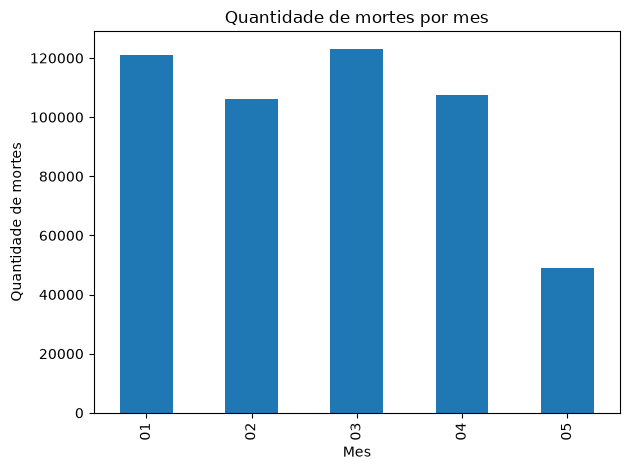

In [210]:
mortes_por_mes.plot(kind='bar', color='#1f77b4')
plt.title('Quantidade de mortes por mes')
plt.xlabel('Mes')
plt.ylabel('Quantidade de mortes')
plt.tight_layout()
plt.show()

**Leitura:** os meses de janeiro a abril têm volumes parecidos, e maio aparece
bem menor. Isso sugere que o mês de maio ainda estava **incompleto** quando a
base foi gerada, então ele deve ser interpretado com cuidado.

## 2) Média, mediana e desvio padrão da idade por mês

Usamos `groupby('MES')` para separar por mês e pedimos três medidas de uma vez:
média (`mean`), mediana (`median`) e desvio padrão (`std`).

In [211]:
idade_por_mes = mortes.groupby('MES')['IDADE_ANOS'].agg(['mean', 'median', 'std'])
idade_por_mes = idade_por_mes.round(1)
idade_por_mes.columns = ['Media', 'Mediana', 'Desvio_padrao']
print(idade_por_mes)

     Media  Mediana  Desvio_padrao
MES                               
01    67.1     71.0           21.1
02    66.9     71.0           21.3
03    67.3     71.0           21.2
04    67.5     72.0           21.2
05    67.7     72.0           21.2


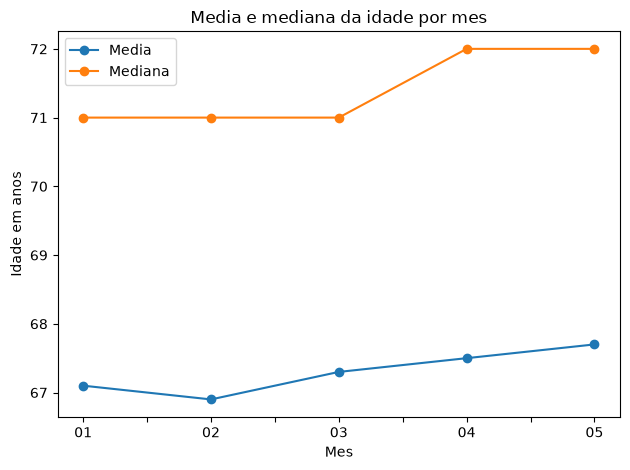

In [212]:
idade_por_mes[['Media', 'Mediana']].plot(marker='o')
plt.title('Media e mediana da idade por mes')
plt.xlabel('Mes')
plt.ylabel('Idade em anos')
plt.tight_layout()
plt.show()

**Leitura:** a idade média dos óbitos fica em torno de 67 anos e é bastante
estável ao longo dos meses. A mediana (71–72 anos) é sempre maior que a média,
o que acontece porque as mortes de bebês e jovens puxam a média para baixo.

## 3) Quantidade de mortes por estado, no semestre

Como a base cobre de janeiro a maio de 2026 (primeiro semestre), basta contar
quantas mortes houve em cada estado (`UF`).

In [213]:
mortes_por_estado = mortes['UF'].value_counts()
print(mortes_por_estado)

UF
SP    114785
MG     49372
RJ     48198
BA     34592
PR     30283
RS     30137
PE     23392
CE     23081
SC     17437
PA     16817
MA     14972
GO     14874
PB     11092
ES      9233
PI      8379
MT      8144
RN      8039
AL      7687
MS      6913
AM      6811
DF      5767
SE      5448
RO      3630
TO      3456
AC      1554
AP      1410
RR      1025
Name: count, dtype: int64


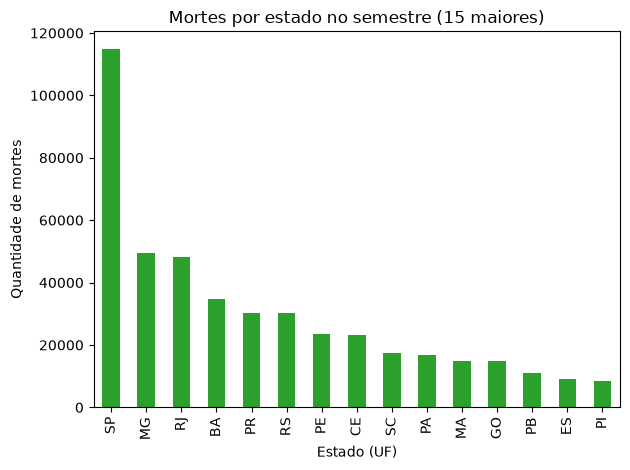

In [214]:
mortes_por_estado.head(15).plot(kind='bar', color='#2ca02c')
plt.title('Mortes por estado no semestre (15 maiores)')
plt.xlabel('Estado (UF)')
plt.ylabel('Quantidade de mortes')
plt.tight_layout()
plt.show()

**Leitura:** São Paulo lidera com folga, seguido por Minas Gerais e Rio de
Janeiro. Atenção: isso é **volume total**. Estados mais populosos naturalmente
têm mais óbitos, então esse número sozinho não indica maior risco de morrer.

## 4) Quantidade de mortes por CID

Aqui contamos quantas mortes houve para cada código de doença.

In [215]:
mortes_por_cid = mortes['CAUSABAS'].value_counts()
print('Quantidade de CIDs diferentes:', len(mortes_por_cid))
print()
print('Os 15 CIDs com mais mortes:')
print(mortes_por_cid.head(15))

Quantidade de CIDs diferentes: 4470

Os 15 CIDs com mais mortes:
CAUSABAS
I219    27211
J189    20220
R99     17991
N390    11127
I10     10751
C349    10447
I64      9822
G309     9636
A419     7915
C509     7155
E149     7049
J440     6727
C61      6281
I509     6087
J159     5311
Name: count, dtype: int64


## 5) As 10 maiores causas e o percentual de cada uma

Agora usamos a **descrição** da doença (que veio do merge) e calculamos o
percentual de cada causa em relação ao total de óbitos.

In [216]:
top10_causas = mortes['DESCRICAO_CID'].value_counts().head(10)

# Montamos uma tabela com a contagem e o percentual sobre o total
tabela_causas = pd.DataFrame()
tabela_causas['Mortes'] = top10_causas
tabela_causas['Percentual'] = (top10_causas / len(mortes) * 100).round(2)
print(tabela_causas)

                                                    Mortes  Percentual
DESCRICAO_CID                                                         
Infarto agudo do miocárdio não especificado          27211        5.37
Pneumonia não especificada                           20220        3.99
Outras causas mal definidas e as não especifica...   17991        3.55
Infecção do trato urinário de localização não e...   11127        2.20
Hipertensão essencial (primária)                     10751        2.12
Neoplasia maligna dos brônquios ou pulmões, não...   10447        2.06
Acidente vascular cerebral, não especificado co...    9822        1.94
Doença de Alzheimer não especificada                  9636        1.90
Septicemia não especificada                           7915        1.56
Neoplasia maligna da mama, não especificada           7155        1.41


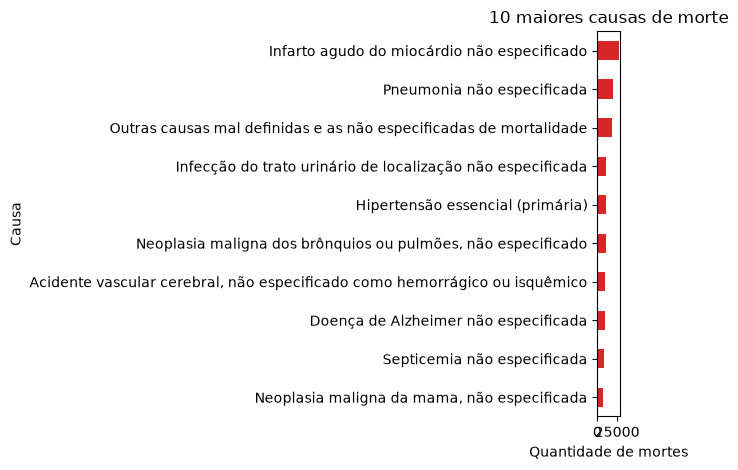

In [217]:
top10_causas.sort_values().plot(kind='barh', color='#d62728')
plt.title('10 maiores causas de morte')
plt.xlabel('Quantidade de mortes')
plt.ylabel('Causa')
plt.tight_layout()
plt.show()

**Leitura:** o infarto agudo do miocárdio é a maior causa isolada (cerca de
5% de todos os óbitos), seguido por pneumonia. Aparece também "Outras causas mal
definidas", que reúne registros sem diagnóstico preciso — um sinal de qualidade
do preenchimento que vale acompanhar.

## 6) Quantidade de mortes por faixa de idade e sexo

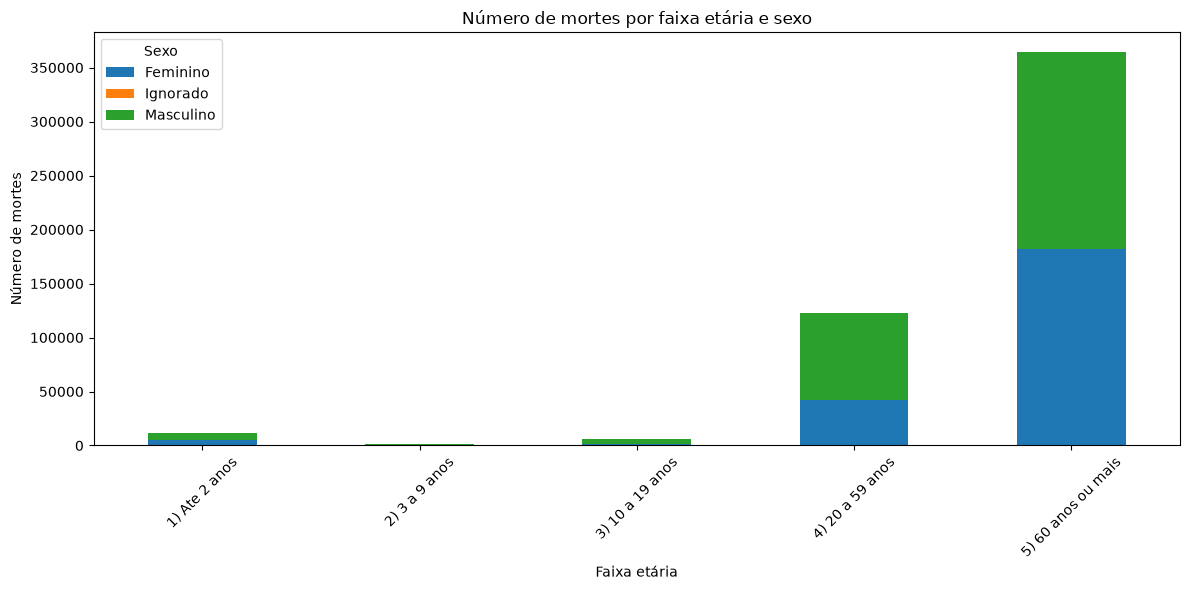

In [218]:
pivot = pd.pivot_table(
    mortes,
    index='FAIXA_IDADE',
    columns='SEXO',
    values='IDADE_ANOS',
    aggfunc='count'
)

pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Número de mortes por faixa etária e sexo')
plt.xlabel('Faixa etária')
plt.ylabel('Número de mortes')
plt.xticks(rotation=45)
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()

**Leitura:** a grande maioria dos óbitos acontece na faixa de 60 anos ou
mais, como era de se esperar. Chama atenção a faixa "até 2 anos", que concentra
a mortalidade infantil e é bem maior que as faixas de crianças e jovens.
Em relaçao ao sexo, houve uma diferença considerável entre a mortalidade de homens e mulheres na faixa etária 3 e 4

## 7) As 10 cidades onde mais pessoas morreram

In [219]:
top10_cidades = mortes['MUNICIPIO'].value_counts().head(10)
print(top10_cidades)

MUNICIPIO
SÃO PAULO         27689
RIO DE JANEIRO    22019
FORTALEZA          8377
RECIFE             8242
BELO HORIZONTE     7431
SALVADOR           7233
CURITIBA           6055
BRASILIA           5767
PORTO ALEGRE       5608
BELÉM              5201
Name: count, dtype: int64


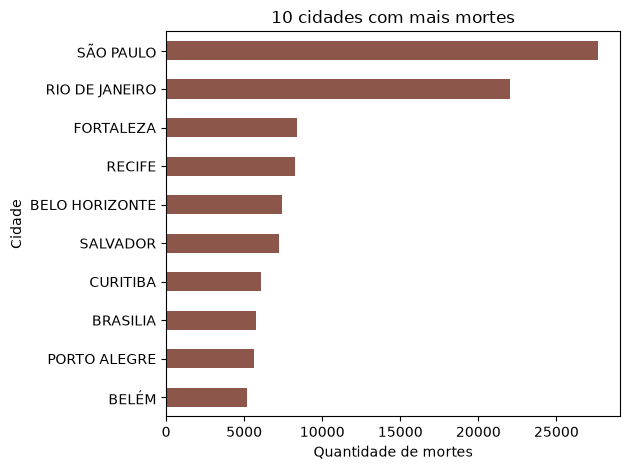

In [220]:
top10_cidades.sort_values().plot(kind='barh', color='#8c564b')
plt.title('10 cidades com mais mortes')
plt.xlabel('Quantidade de mortes')
plt.ylabel('Cidade')
plt.tight_layout()
plt.show()

**Leitura:** as maiores cidades do país (São Paulo, Rio de Janeiro,
Fortaleza...) lideram. De novo, é **volume**: cidades grandes têm mais mortes
simplesmente porque têm mais gente. A pergunta 8 corrige isso usando a
população.

## 8) Percentual de óbitos por população (mortes proporcionais)

Para comparar cidades de tamanhos diferentes de forma justa, dividimos o número
de mortes pela população. Assim descobrimos onde se morreu **mais em proporção**,
e não só em número absoluto.

Primeiro juntamos, para cada cidade, o total de mortes e a população. Usamos
`groupby` com duas medidas ao mesmo tempo: contar as mortes e pegar a população.

In [221]:
# Agrupar por cidade e estado, contando mortes e pegando a populacao
por_cidade = mortes.groupby(['MUNICIPIO', 'UF']).agg(
    Mortes=('CAUSABAS', 'size'),
    Populacao=('POPULACAO', 'first')
).reset_index()

# Calcular mortes por 100 mil habitantes
por_cidade['Mortes_por_100mil'] = (por_cidade['Mortes'] / por_cidade['Populacao'] * 100000).round(1)

# Para nao dar destaque a vilarejos com pouquissimos casos, olhamos apenas
# cidades com pelo menos 20 mortes no periodo.
por_cidade = por_cidade[por_cidade['Mortes'] >= 20]

proporcional = por_cidade.sort_values('Mortes_por_100mil', ascending=False).head(10)
print(proporcional.to_string(index=False))

            MUNICIPIO UF  Mortes  Populacao  Mortes_por_100mil
        PARIQUERA-AÇU SP     273    19260.0             1417.4
CAMPINA GRANDE DO SUL PR     684    52083.0             1313.3
       AUGUSTINÓPOLIS TO     203    17471.0             1161.9
       PAU DOS FERROS RN     346    30403.0             1138.0
          PORTO CALVO AL     248    23708.0             1046.1
     TROMBUDO CENTRAL SC      70     7074.0              989.5
             BARRETOS SP    1045   119427.0              875.0
               URUAÇU GO     382    43728.0              873.6
              JOAÇABA SC     251    29976.0              837.3
          CAMPO LARGO PR    1201   144165.0              833.1


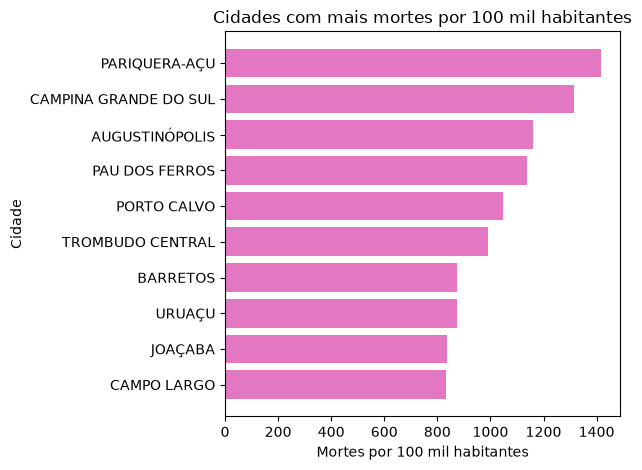

In [222]:
proporcional_ordenado = proporcional.sort_values('Mortes_por_100mil')
plt.barh(proporcional_ordenado['MUNICIPIO'], proporcional_ordenado['Mortes_por_100mil'], color='#e377c2')
plt.title('Cidades com mais mortes por 100 mil habitantes')
plt.xlabel('Mortes por 100 mil habitantes')
plt.ylabel('Cidade')
plt.tight_layout()
plt.show()

**Leitura:** quando olhamos pela proporção, quem aparece no topo são cidades
**pequenas**, e não as capitais. Isso mostra como a conclusão muda ao considerar
o tamanho da população. Ainda assim, é uma taxa **bruta** do período: em cidades
pequenas, poucas mortes já mudam muito o resultado, por isso usamos o corte de 20
mortes para dar um mínimo de estabilidade.

## 9) IQR, histograma, curva de distribuição e z-score da idade

Nesta pergunta usamos o **numpy** para fazer os cálculos. Ele é ótimo para
trabalhar com muitos números de uma vez.

Primeiro, transformamos a coluna de idade em um "vetor" do numpy (uma sequência
de números) e já deixamos de fora os valores vazios.

In [223]:
# .dropna() tira os vazios; .to_numpy() transforma a coluna em um vetor do numpy
idades = mortes['IDADE_ANOS'].dropna().to_numpy()

print('Quantidade de idades:', len(idades))
print('Tipo do objeto:', type(idades))

Quantidade de idades: 506113
Tipo do objeto: <class 'numpy.ndarray'>


### IQR com numpy

**IQR** (intervalo interquartil) é a diferença entre o quartil de 75% (Q3) e o de
25% (Q1). Ele mostra a faixa onde estão os 50% centrais das idades. Usamos a
função `np.percentile` para achar Q1 e Q3 de uma vez.

In [224]:
# np.percentile calcula os percentis pedidos
q1, q3 = np.percentile(idades, [25, 75])
iqr = q3 - q1

print('Q1 (25%):', q1)
print('Q3 (75%):', q3)
print('IQR (Q3 - Q1):', iqr)
print('Limite inferior (Q1 - 1.5*IQR):', q1 - 1.5 * iqr)
print('Limite superior (Q3 + 1.5*IQR):', q3 + 1.5 * iqr)

Q1 (25%): 57.0
Q3 (75%): 82.0
IQR (Q3 - Q1): 25.0
Limite inferior (Q1 - 1.5*IQR): 19.5
Limite superior (Q3 + 1.5*IQR): 119.5


### Histograma por faixa de idade

O histograma mostra quantas pessoas morreram em cada faixa de idade. É a forma
mais simples de ver o "formato" da distribuição.

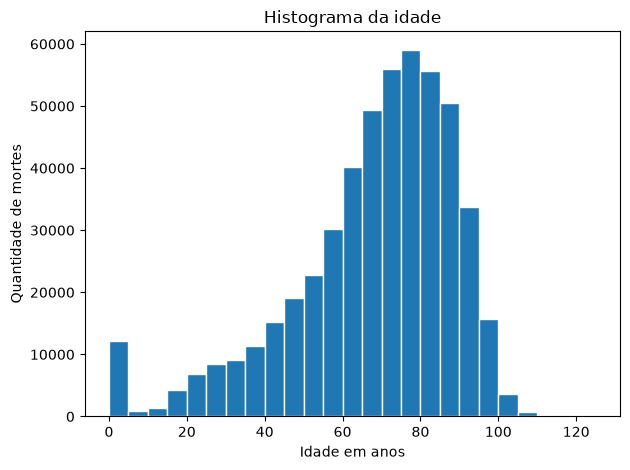

In [225]:
plt.hist(idades, bins=range(0, 130, 5), color='#1f77b4', edgecolor='white')
plt.title('Histograma da idade')
plt.xlabel('Idade em anos')
plt.ylabel('Quantidade de mortes')
plt.tight_layout()
plt.show()

**Leitura:** o histograma mostra que a maioria das mortes se concentra entre
70 e 90 anos, com um pequeno pico logo no começo (mortalidade de bebês). A curva
acumulada confirma: ela sobe devagar no início e cresce forte a partir dos 60
anos.

### Coluna de z-score com numpy

O **z-score** diz a quantos desvios padrão cada idade está da média. Fórmula
simples: `(idade - média) / desvio padrão`. Usamos `np.mean` para a média e
`np.std` para o desvio padrão. Um z-score de 0 é exatamente a média; valores
acima de +3 ou abaixo de -3 são considerados bem distantes do comum.

In [226]:
# numpy calcula a media e o desvio padrao de todas as idades
media = np.mean(idades)
desvio = np.std(idades)

# Criamos a nova coluna aplicando a formula do z-score em toda a tabela
mortes['Z_SCORE_IDADE'] = (mortes['IDADE_ANOS'] - media) / desvio

print('Media da idade:', round(media, 1))
print('Desvio padrao da idade:', round(desvio, 1))
print()
print('Exemplos da nova coluna de z-score:')
print(mortes[['IDADE_ANOS', 'Z_SCORE_IDADE']].dropna().head(10).round(2).to_string(index=False))

Media da idade: 67.2
Desvio padrao da idade: 21.2

Exemplos da nova coluna de z-score:
 IDADE_ANOS  Z_SCORE_IDADE
       98.0           1.45
       90.0           1.07
       51.0          -0.77
       96.0           1.36
       95.0           1.31
       76.0           0.41
       71.0           0.18
       72.0           0.22
       95.0           1.31
       75.0           0.37


**Observação importante:** aqui **não apagamos** as idades muito altas ou
muito baixas. Em uma base de mortes, um bebê ou uma pessoa de 110 anos são casos
reais, e não erros. O IQR e o z-score servem para **identificar** esses casos
extremos, não para excluí-los.

## Conclusões

1. **O tempo:** de janeiro a abril o número de mortes é estável (perto de 110 a
   120 mil por mês); maio aparece incompleto e não deve ser comparado diretamente.
2. **A idade:** a idade típica de óbito gira em torno de 71 anos (mediana), e mais
   de 70% das mortes ocorrem a partir dos 60 anos.
3. **As causas:** infarto e pneumonia são as maiores causas isoladas; juntas, as
   dez maiores causas explicam boa parte dos óbitos.
4. **O território:** em número absoluto, as capitais lideram; mas, ajustando pela
   população, quem se destaca são cidades pequenas — o que muda completamente a
   conclusão.

### Limitações
- A base cobre apenas parte de 2026 e o mês de maio parece incompleto.
- As taxas por população são **brutas**: não ajustam por idade nem por ano cheio.
- Algumas mortes estão em "causas mal definidas", o que limita a análise por CID.

## Próximos passos:
- Analisar outros anos para fins de comparação e evolução de doenças específicas
- Analisar os dados de morte de bebês, para idenficar os principais motivos
- Analisar os casos de acidentes de trabalho

